In [288]:
import numpy as np

In [289]:
### Logic gates data ###
mxor = np.array([[ 0 , 0 , 0 ],
                 [ 0 , 1 , 1 ],
                 [ 1 , 0 , 1 ],
                 [ 1 , 1 , 0]])
data = np.copy(mxor)

In [290]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
  fx = sigmoid(x)
  return fx * (1 - fx)

def mse_loss(y_true, y_pred):
  return ((y_true - y_pred) ** 2).mean()

x = data[:,0:2]     # Inputs, acessing all arrays in mxor, but just taking 0 , 1 items, 4 arrays x 2 inputs each one
y = data[:,2:3]     # Outputs, accessing all arrays in mxor, but just taking the 2nd item, 4 arrays x 1 output each one

n, I = np.shape(x)  # number of inputs (2)
n, J = np.shape(y)  # number of outputs (1)

H = 2 # number of hidden neurons
w = np.random.normal(scale=0.5, size=(I, H))  # input to hidden weigths
b = np.random.normal(scale=0.5, size=H)       # hidden biases
w2 = np.random.normal(scale=0.5, size=(H, J)) # hidden to output biases
b2 = np.random.normal(scale=0.5, size=J)      # output biases

print(w)

[[ 0.45017282 -0.60993301]
 [-0.5953513   0.63084232]]


In [291]:
def layer(x, w, b):
  z = np.dot(x, w)
  z = z + b
  return sigmoid(z)

def predict(x, w, b, w2, b2):
  hidden_layer_output = layer(x, w, b)
  output_layer = layer(hidden_layer_output, w2, b2)
  y_pred = output_layer
  return y_pred


In [292]:
def train(x,y,w,b,w2,b2):
  best_loss = 10e10
  # forward propagation
  h = layer(x, w, b)         #hidden layer
  y_pred = layer(h, w2, b2)  #output layer
  loss = mse_loss(y, y_pred) # loss

  if loss < best_loss:
    best_loss = loss
    print(loss)

  while best_loss > 0.1:
    w = np.random.normal(scale=10, size=(I, H))  # input to hidden weigths
    b = np.random.normal(scale=10, size=H)       # hidden biases
    w2 = np.random.normal(scale=10, size=(H, J)) # hidden to output biases
    b2 = np.random.normal(scale=10, size=J)      # output biases

    # forward propagation
    h = layer(x, w, b)         #hidden layer
    y_pred = layer(h, w2, b2)  #output layer
    # loss
    loss = mse_loss(y, y_pred)
    if loss < best_loss:
      best_loss = loss
      print(loss)
      bestw = np.copy(w)
      bestb = np.copy(b)
      bestw2 = np.copy(w2)
      bestb2 = np.copy(b2)
  return bestw, bestb, bestw2, bestb2

w, b, w2, b2 = train(x,y,w,b,w2,b2)
y_pred = predict(x, w, b, w2, b2)
print(y_pred)
y_pred = np.round(y_pred)
print(y_pred)
print(y)

0.2539206080871476
0.189114182850377
0.15935558375430156
0.13402961617389464
0.08421322488203732
[[0.2557039 ]
 [0.56539541]
 [0.81875164]
 [0.22301636]]
[[0.]
 [1.]
 [1.]
 [0.]]
[[0]
 [1]
 [1]
 [0]]


In [293]:
### Training by the sci-kit learn ann library ###

import sklearn
from sklearn.neural_network import MLPClassifier

model = sklearn.neural_network.MLPClassifier(
    activation='relu', max_iter=10000, hidden_layer_sizes=(2))
model.fit(x, y.ravel())
y_pred = model.predict(x)

print('Predictions (stochastic gradient descent):',y_pred)
print('Targets:', y.ravel())


Predictions (stochastic gradient descent): [0 0 0 0]
Targets: [0 1 1 0]


Predictions on training set: [0 1 1 0]
Predicted class probabilities (prob of class 1):
[0.15114396 0.8992099  0.89890158 0.15912022]
Training accuracy: 1.0


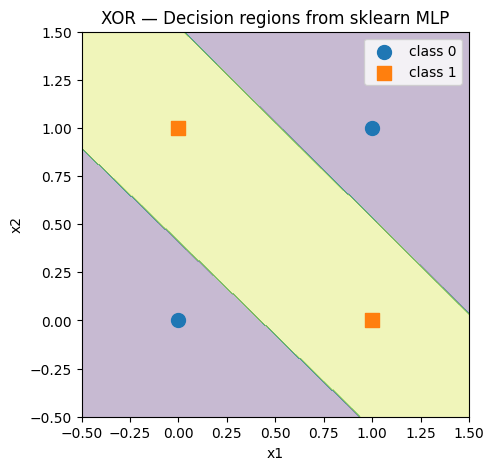

In [294]:
# xor_sklearn.py
import numpy as np
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# MLP: one hidden layer with 2 neurons
# - activation='tanh' -> symmetric nonlinearity works well for XOR
# - random_state for reproducibility
'''for more layers we just need to keep adding # of neurons per layer,
       like hidden_layer_sizes = (h1, h2, h3, ...),
       means h1 neurons at first layer, h2 neurons at 2nd and so on..'''
clf = MLPClassifier(
    hidden_layer_sizes=(2,),    # 1 hidden layer with 2 neurons
    activation='tanh',          # can also try 'logistic' or 'relu'
    solver='adam',
    max_iter=1000000,
    random_state=5
)

# Train
y = y.ravel()
clf.fit(x, y)

# Inspect predictions & probabilities
print("Predictions on training set:", clf.predict(X))
print("Predicted class probabilities (prob of class 1):")
print(clf.predict_proba(X)[:, 1])
print("Training accuracy:", clf.score(X, y))

# Plot decision regions for visualization
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 400), np.linspace(-0.5, 1.5, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf.predict(grid).reshape(xx.shape)

plt.figure(figsize=(5,5))
plt.contourf(xx, yy, Z, alpha=0.3)  # decision regions
plt.scatter(x[y==0, 0], x[y==0, 1], marker='o', s=100, label='class 0')  # class 0 points
plt.scatter(x[y==1, 0], x[y==1, 1], marker='s', s=100, label='class 1')  # class 1 points
plt.legend()
plt.title("XOR — Decision regions from sklearn MLP")
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()
